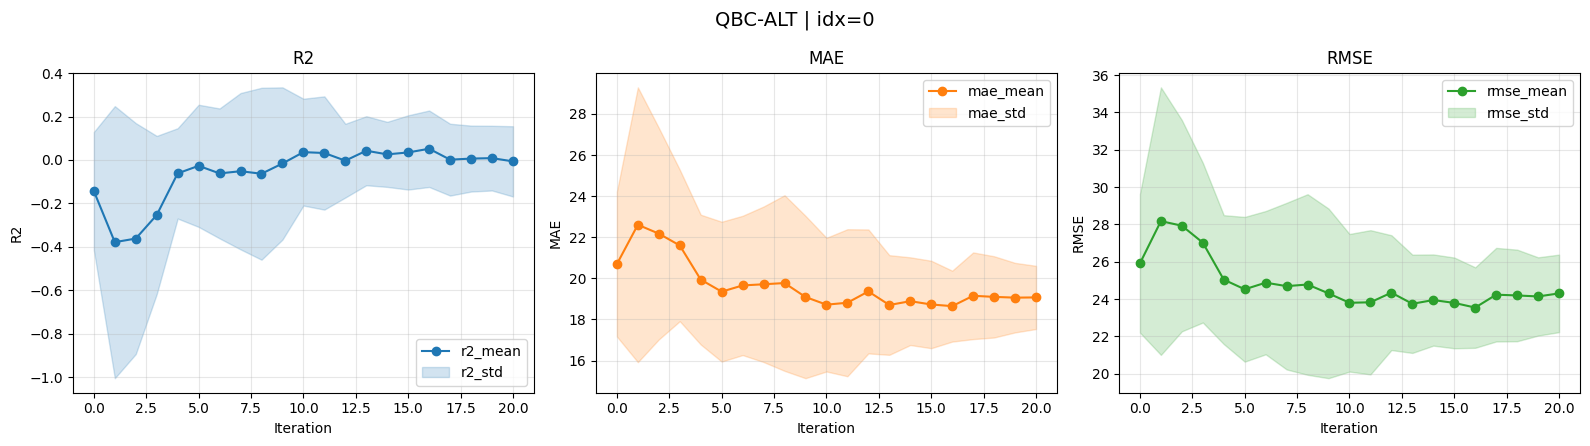

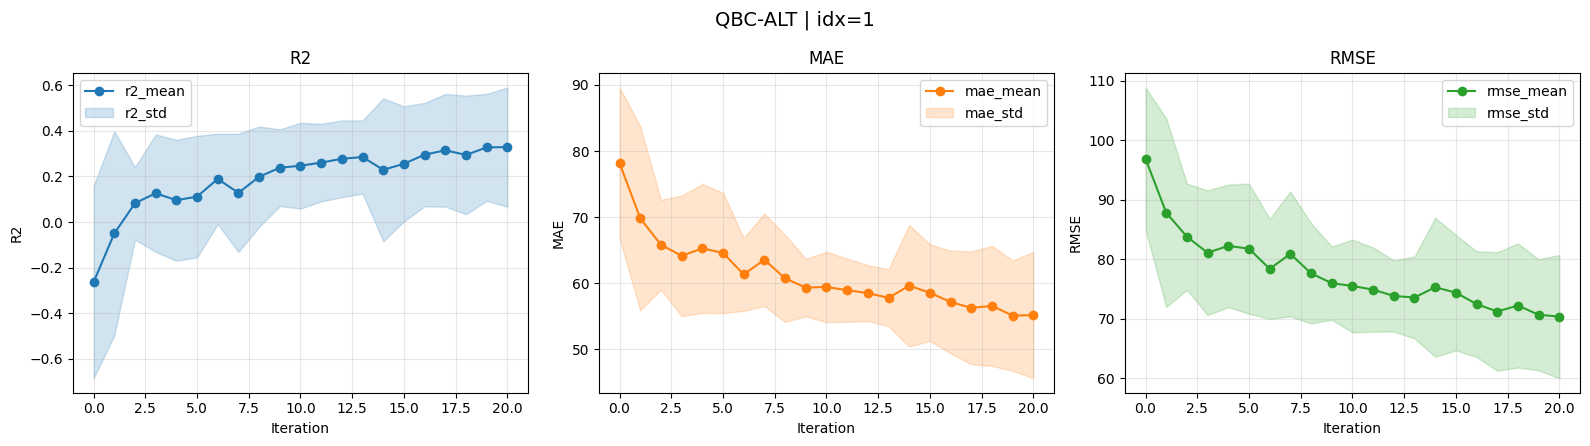

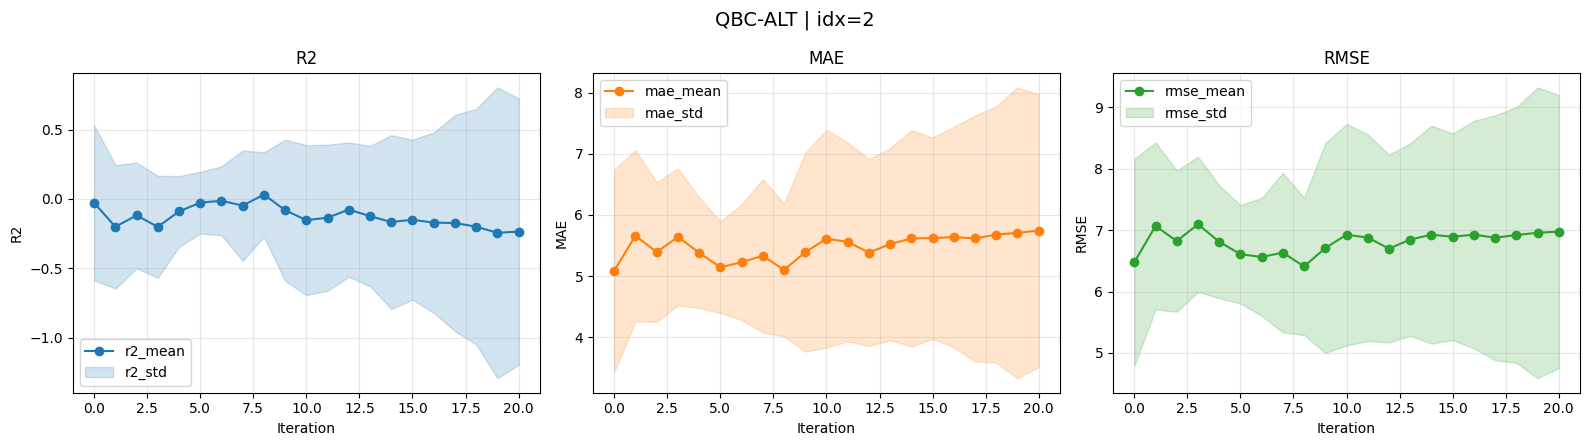

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt

qbc_json = "../result_plot/QBC_ALT_metrics_summary.json"
with open(qbc_json, "r", encoding="utf-8") as f:
    data = json.load(f)

metrics = ["r2", "mae", "rmse"]
colors = {"r2": "tab:blue", "mae": "tab:orange", "rmse": "tab:green"}

# 每个 idx 一张图；图内 3 个子图（r2/mae/rmse 分开）
for idx in ["0", "1", "2"]:
    d = data[idx]
    n = len(d["r2_mean"])
    x = np.arange(n)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f"QBC-ALT | idx={idx}", fontsize=14)

    for ax, m in zip(axes, metrics):
        mean = np.array(d[f"{m}_mean"], dtype=float)
        std = np.array(d[f"{m}_std"], dtype=float)

        ax.plot(x, mean, marker="o", color=colors[m], label=f"{m}_mean")
        ax.fill_between(x, mean - std, mean + std, color=colors[m], alpha=0.2, label=f"{m}_std")
        ax.set_title(m.upper())
        ax.set_xlabel("Iteration")
        ax.set_ylabel(m.upper())
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()
